In [8]:
import numpy as np
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [98]:
class KMeans:
  def __init__(self, n_clusters, max_iters = 100):
    self.n_clusters = n_clusters
    self.iters = max_iters

  def train(self, X_train):
    n, m = X_train.shape
    idx = np.random.choice(n, self.n_clusters, replace = True)
    self.centroids = X_train[idx]

    assinged = np.zeros(n)

    for _ in range(self.iters):
      # for i in range(n):
      #   minDist = float("inf")
      #   for j in range(self.n_clusters):
      #     currDist = np.sqrt(np.sum((self.centroids[j] - X_train[i]) ** 2))

      #     if currDist < minDist:
      #       assinged[i] = j
      #       minDist = currDist

      distances = np.linalg.norm(X_train[:, np.newaxis] - self.centroids, axis = 2)
      assigned = np.argmin(distances, axis = 1)

      # new centroids
      new_centroids = np.zeros((self.n_clusters, m))
      for i in range(self.n_clusters):
        new_centroids[i] = X_train[assigned == i].mean(axis=0)

      if np.allclose(new_centroids, self.centroids):
        break
      else:
        self.centroids = new_centroids

  def predict(self, X_test):
    # y_pred = np.zeros(X_test.shape[0])
    # for i in range(X_test.shape[0]):
    #   minDist = float("inf")
    #   for j in range(self.n_clusters):
    #     currDist = np.sqrt(np.sum((self.centroids[j] - X_test[i]) ** 2))
    #     if currDist < minDist:
    #       y_pred[i] = j
    #       minDist = currDist
    distances = np.linalg.norm(X_test[:, np.newaxis] - self.centroids, axis = 2)
    y_pred = np.argmin(distances, axis = 1)

    return y_pred

In [99]:
np.zeros(100).shape

(100,)

In [100]:
X, y = make_blobs(
    n_samples=100,
    n_features=2,
    centers=3,
    cluster_std=1.0,
    random_state=42
)

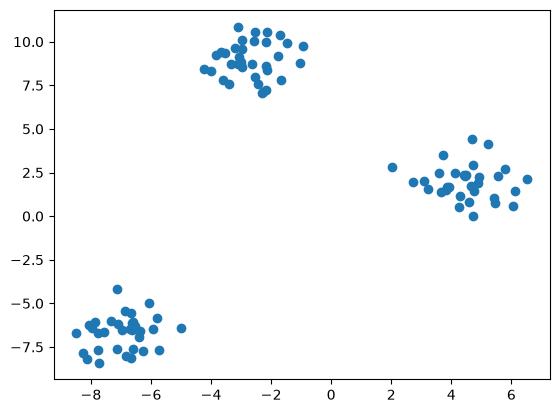

In [101]:
plt.scatter(X[:,0],X[:,1])

In [102]:
kmeans = KMeans(3)

In [103]:
kmeans.train(X)

In [83]:
y_pred = kmeans.predict(X)
y_pred.shape

(100,)

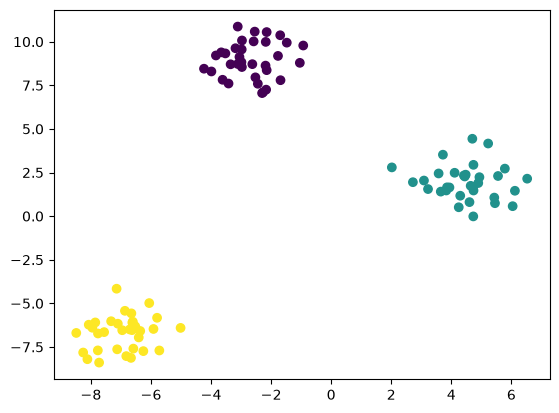

In [104]:
plt.scatter(X[:,0],X[:,1], c = y_pred)